# Myelin Whole Brain Population Distribution & Group Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr
from statsmodels.stats.multitest import multipletests

In [2]:
# Folder to save figures
output_dir = "/home/jovyan/Desktop/PBL_Neuro/postprocessing/Myelin/Scripts/Figures_Class_Distributions"

## Load Data

In [3]:
df = pd.read_csv("/home/jovyan/Desktop/PBL_Neuro/postprocessing/Myelin/Scripts/myelin_features_networks_filtered.csv")
metadata_df = pd.read_csv("../../../eda/OASIS3_metadata_final.csv")

## Extract Whole-Brain Myelin

In [4]:
# Correctly select all 7 network
list_columns_networks = [col for col in df.columns if col.startswith('myelin_')]
print("Networks included:", list_columns_networks)

Networks included: ['myelin_Vis', 'myelin_SomMot', 'myelin_DorsAttn', 'myelin_SalVentAttn', 'myelin_Limbic', 'myelin_Cont', 'myelin_Default']


In [5]:
# Calculate the mean across columns for each subject
df['myelin_whole_brain'] = df[list_columns_networks].mean(axis=1)
print("First few rows with whole-brain myelin:")
print(df[['Subject_ID', 'myelin_whole_brain', 'group','Age']].head(7))

First few rows with whole-brain myelin:
  Subject_ID  myelin_whole_brain     group    Age
0   OAS30001            0.005438   NORMCOG  65.54
1   OAS30002           -0.044835   NORMCOG  69.04
2   OAS30003            0.011631   NORMCOG  60.34
3   OAS30004            0.059374   NORMCOG  58.14
4   OAS30005            0.061962   NORMCOG  49.65
5   OAS30006            0.018629   NORMCOG  65.71
6   OAS30007           -0.119124  DEMENTED  71.76


# Part 1: Population-level Distributions (Histogram & Density Curves)

### 1.1 Histogram Only (Raw Counts)

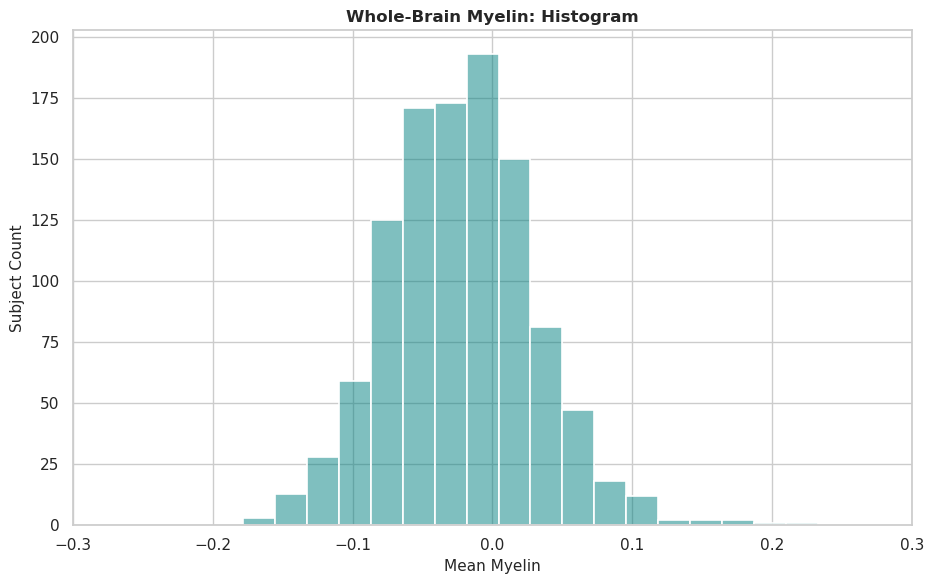

In [6]:
sns.set_theme(style="whitegrid")

# Plotting with actual counts on the y-axis
plt.figure(figsize=(9.5, 6))
sns.histplot(
    data=df, 
    x='myelin_whole_brain', 
    stat='count', 
    color='teal', 
    bins=30, 
    alpha=0.5, 
    edgecolor='white', 
    linewidth=1.2
)

plt.title('Whole-Brain Myelin: Histogram', fontsize=12, fontweight='bold')
plt.xlabel('Mean Myelin', fontsize=11);plt.ylabel('Subject Count', fontsize=11);plt.xlim(-0.3,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '1_1_histogram_raw_counts.png'), dpi=300, bbox_inches='tight')
plt.show()


### 1.2 Density Curve (KDE) Only (Probability Density)

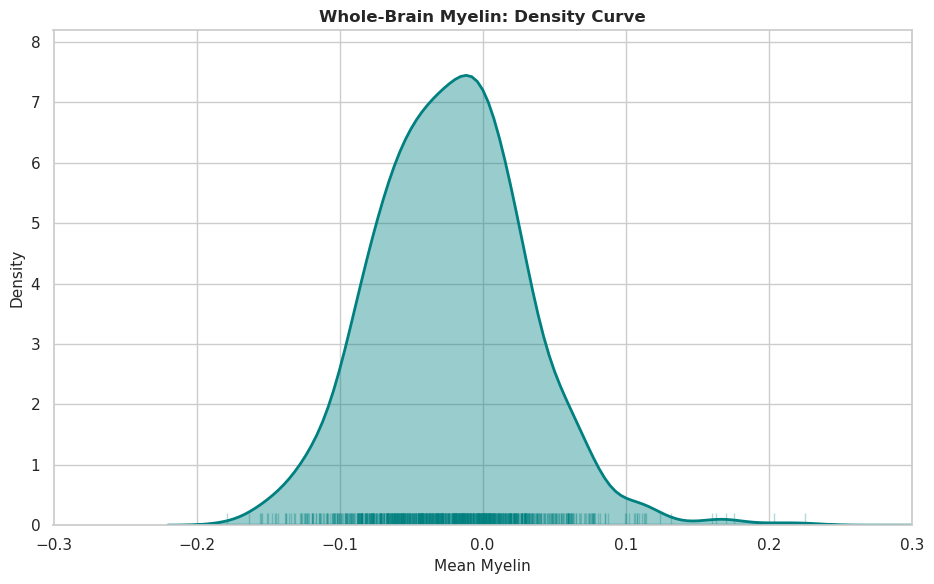

In [7]:
# KDE shows probability density
plt.figure(figsize=(9.5, 6))
sns.kdeplot(
    data=df, 
    x='myelin_whole_brain', 
    fill=True, 
    color='teal', 
    linewidth=2, 
    alpha=0.4
)
sns.rugplot(data=df, x='myelin_whole_brain', color='teal', alpha=0.3)

plt.title('Whole-Brain Myelin: Density Curve', fontsize=12, fontweight='bold')
plt.xlabel('Mean Myelin', fontsize=11);plt.ylabel('Density', fontsize=11);plt.xlim(-0.3,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '1_2_density_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

### 1.3 Histogram & Density Curve Overlaid (All Together)

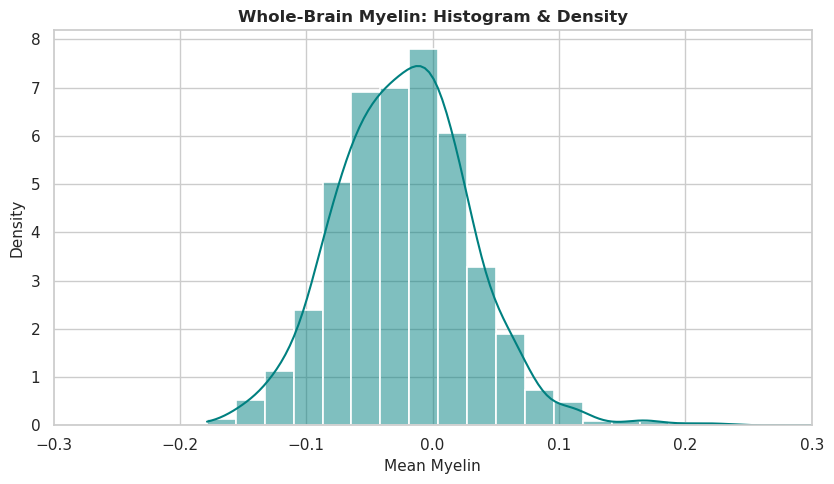

In [8]:
# Overlaid plots must use density so the KDE line is on the correct scale
plt.figure(figsize=(8.5, 5))
sns.histplot(
    data=df, 
    x='myelin_whole_brain', 
    kde=True, 
    stat='density', 
    color='teal', 
    bins=30, 
    alpha=0.5, 
    edgecolor='white', 
    linewidth=1.2
)

plt.title('Whole-Brain Myelin: Histogram & Density', fontsize=12, fontweight='bold')
plt.xlabel('Mean Myelin', fontsize=11);plt.ylabel('Density', fontsize=11);plt.xlim(-0.3,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '1_3_histogram_density_overlaid.png'), dpi=300, bbox_inches='tight')
plt.show()

# Part 2: Clinical Group Distributions (Separately & Together)

### 2.1 Cognitively Normal (CN)

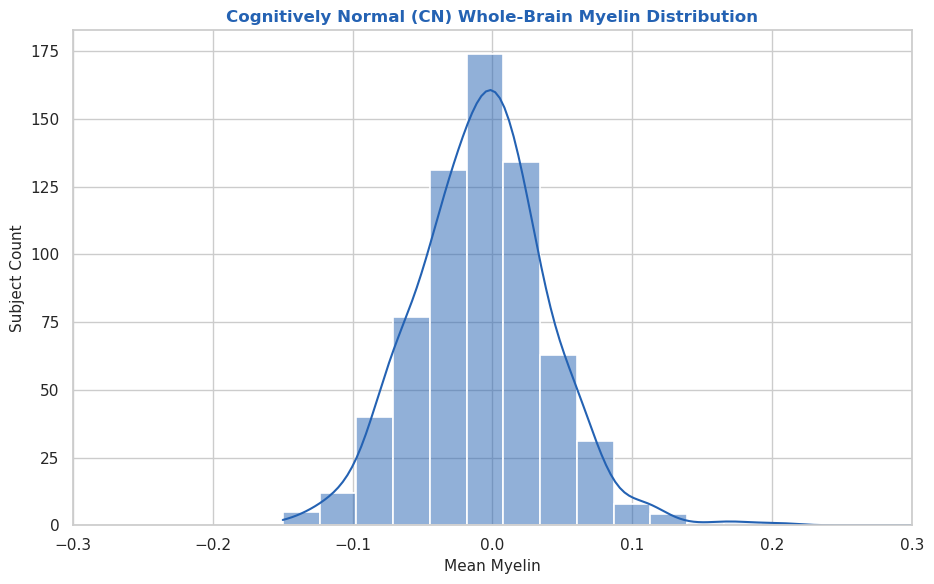

In [9]:
# CN group separately
plt.figure(figsize=(9.5, 6))

sns.histplot(
    data=df[df['group'] == 'NORMCOG'], 
    x='myelin_whole_brain', 
    kde=True, 
    stat='count', 
    color='#2462B3', 
    bins=25, 
    alpha=0.5, 
    edgecolor='white', 
    linewidth=1.2
)

plt.title('Cognitively Normal (CN) Whole-Brain Myelin Distribution', fontsize=12, fontweight='bold', color='#2462B3')
plt.xlabel('Mean Myelin', fontsize=11);plt.ylabel('Subject Count', fontsize=11);plt.xlim(-0.3,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '2_1_cn_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

### 2.2 Alzheimer\'s Disease (AD)

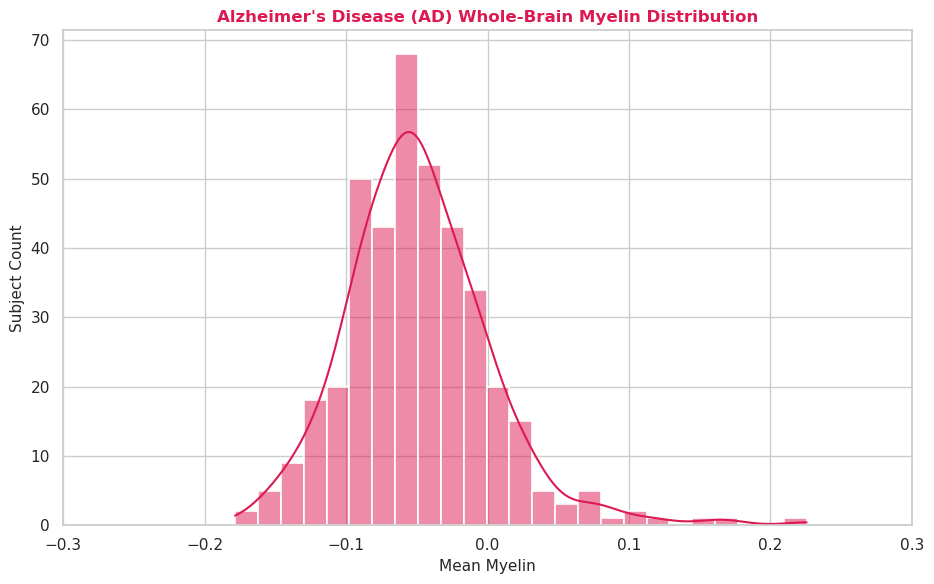

In [10]:
# AD group separately using actual subject counts
plt.figure(figsize=(9.5, 6))

sns.histplot(
    data=df[df['group'] == 'DEMENTED'], 
    x='myelin_whole_brain', 
    kde=True, 
    stat='count', 
    color='#DD1952', 
    bins=25, 
    alpha=0.5, 
    edgecolor='white', 
    linewidth=1.2
)

plt.title('Alzheimer\'s Disease (AD) Whole-Brain Myelin Distribution', fontsize=12, fontweight='bold', color='#DD1952')
plt.xlabel('Mean Myelin', fontsize=11);plt.ylabel('Subject Count', fontsize=11);plt.xlim(-0.3,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '2_2_ad_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

### 2.3 CN & AD Together

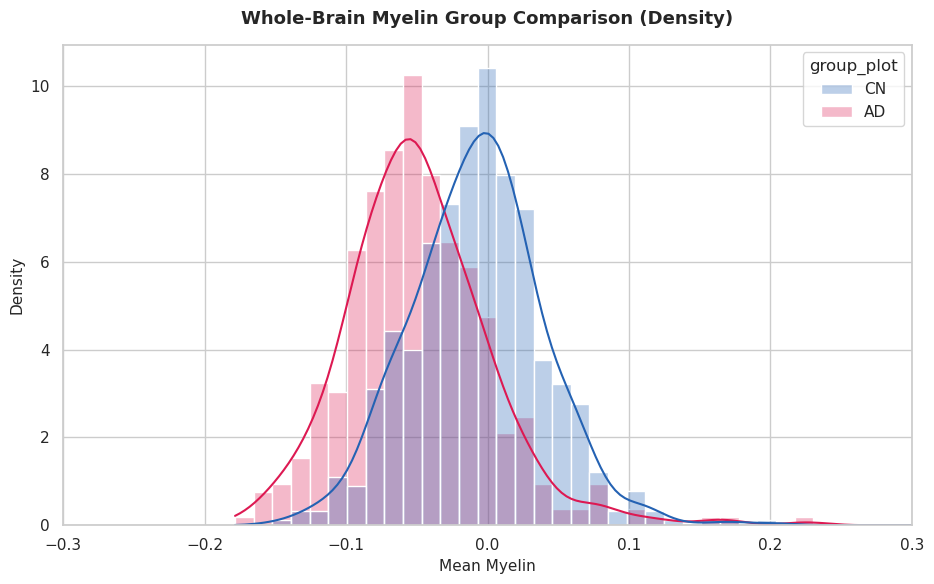

In [11]:
df['group_plot'] = df['group'].replace({'NORMCOG': 'CN', 'DEMENTED': 'AD'})
# Overlaid plot must use density to fairly compare groups with different sample sizes (CN=684 vs AD=399)
plt.figure(figsize=(9.5, 6))
sns.histplot(
    data=df, 
    x='myelin_whole_brain', 
    hue='group_plot', 
    kde=True, 
    stat='density', 
    common_norm=False, 
    palette={'CN': '#2462B3', 'AD': '#DD1952'},
    alpha=0.3, 
    edgecolor='white', 
    linewidth=1.0
)

plt.title('Whole-Brain Myelin Group Comparison (Density)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean Myelin', fontsize=11);plt.ylabel('Density', fontsize=11);plt.xlim(-0.3,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '2_3_group_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()


# Part 3: Overall Myelin Comparison

In [12]:
# Separate group values
ad_myelin = df[df['group'] == 'DEMENTED']['myelin_whole_brain'].dropna()
cn_myelin = df[df['group'] == 'NORMCOG']['myelin_whole_brain'].dropna()

print(f"AD Group (DEMENTED) Size: {len(ad_myelin)}, Mean Myelin: {ad_myelin.mean():.6f} (std: {ad_myelin.std():.6f})")
print(f"CN Group (NORMCOG)  Size: {len(cn_myelin)}, Mean Myelin: {cn_myelin.mean():.6f} (std: {cn_myelin.std():.6f})")

# Perform independent t-test (does not assume equal variances)
t_stat, p_val_two_sided = ttest_ind(ad_myelin, cn_myelin, equal_var=False)

# Perform one-sided t-test (AD < CN)
t_stat, p_val_one_sided = ttest_ind(ad_myelin, cn_myelin, equal_var=False, alternative='less')

print("\n--- Independent T-Test Results---")
print(f"t-statistic: {t_stat:.4f}")
print(f"Two-sided p-value: {p_val_two_sided:.2e}")
print(f"One-sided p-value (AD < CN): {p_val_one_sided:.2e}")

# Significance ?
alpha = 0.05
if p_val_one_sided < alpha:
    print(f"\nResult: STATISTICALLY SIGNIFICANT. The mean whole-brain myelin in the AD group is significantly lower than in the CN group (p < {alpha}).")
else:
    print(f"\nResult: NOT STATISTICALLY SIGNIFICANT. There is no significant evidence that whole-brain myelin is lower in AD (p >= {alpha}).")

AD Group (DEMENTED) Size: 399, Mean Myelin: -0.048625 (std: 0.051441)
CN Group (NORMCOG)  Size: 684, Mean Myelin: -0.005907 (std: 0.052906)

--- Independent T-Test Results---
t-statistic: -13.0449
Two-sided p-value: 1.36e-35
One-sided p-value (AD < CN): 6.82e-36

Result: STATISTICALLY SIGNIFICANT. The mean whole-brain myelin in the AD group is significantly lower than in the CN group (p < 0.05).


# Part 4: Effect of Age
#### Scatter plot of Age vs Whole Brain Myelin 

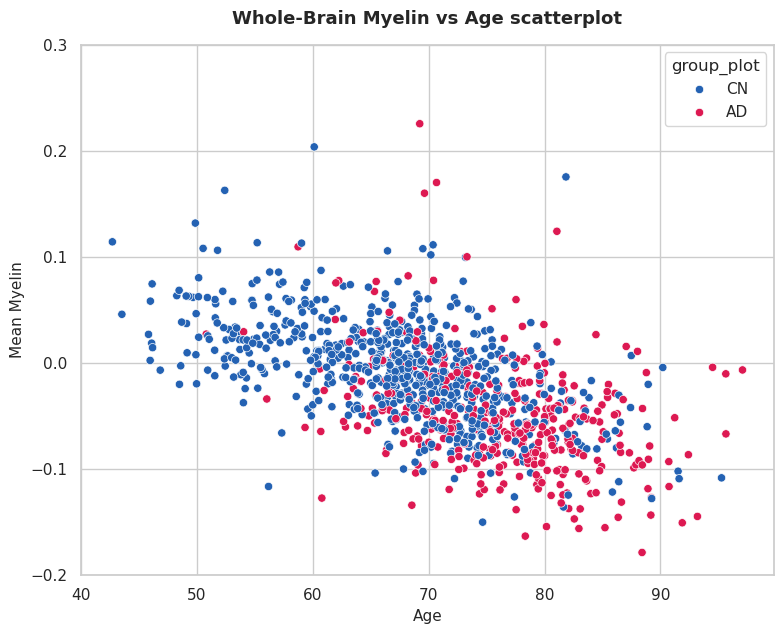

In [13]:
plt.figure(figsize=(8, 6.5))
sns.scatterplot(
    data=df, 
    x='Age', 
    y='myelin_whole_brain',
    hue='group_plot', 
    palette={'CN': '#2462B3', 'AD': '#DD1952'},
)

plt.title('Whole-Brain Myelin vs Age scatterplot', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=11);plt.ylabel('Mean Myelin', fontsize=11);plt.ylim(-0.2,0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '4_Scatterplot(age vs myelin).png'), dpi=300, bbox_inches='tight')
plt.show()

#### Scatterplot and regression line

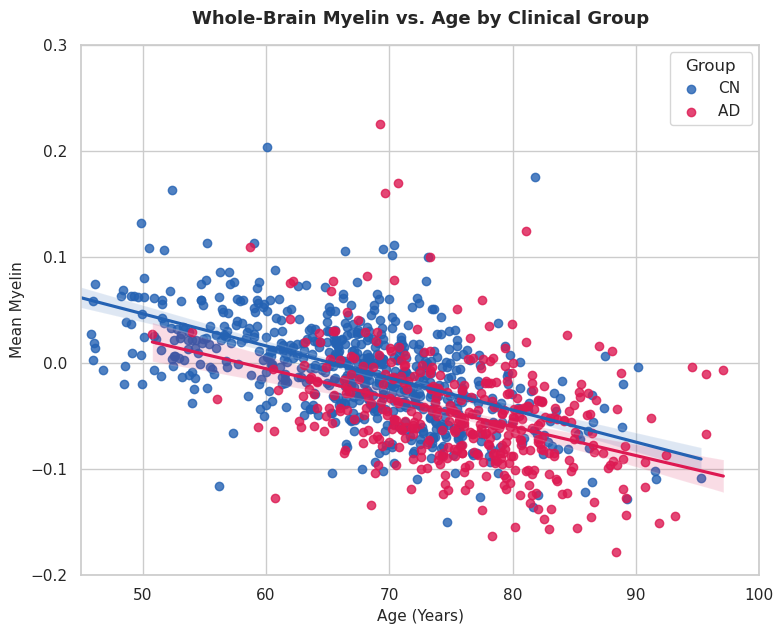

In [14]:
# Plot CN
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6.5))

sns.regplot(
    data=df[df['group'] == 'NORMCOG'], 
    x='Age', 
    y='myelin_whole_brain', 
    color='#2462B3', 
    label='CN', 
)

# Plot AD
sns.regplot(
    data=df[df['group'] == 'DEMENTED'], 
    x='Age', 
    y='myelin_whole_brain', 
    color='#DD1952', 
    label='AD ', 
)

plt.title('Whole-Brain Myelin vs. Age by Clinical Group', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=11);plt.ylabel('Mean Myelin', fontsize=11);plt.xlim(45, 100);plt.ylim(-0.2, 0.3)
plt.legend(title='Group', loc='upper right', frameon=True)
plt.tight_layout();
plt.savefig(os.path.join(output_dir, '4_myelin_vs_age_regression.png'), dpi=300, bbox_inches='tight')
plt.show()

#### Correlation Between Mean Myelin and Age

Pearson correlation coefficient between Age and whole-brain myelin for all subjects, and within clinical groups to quantify the aging effect.

In [15]:
# Overall correlation
corr_all, p_all = pearsonr(df['Age'], df['myelin_whole_brain'])
print(f"Overall Population: r = {corr_all:.4f} (p-value: {p_all:.2e})")

# AD group correlation
ad_df = df[df['group'] == 'DEMENTED']
corr_ad, p_ad = pearsonr(ad_df['Age'], ad_df['myelin_whole_brain'])
print(f"AD Group: r = {corr_ad:.4f} (p-value: {p_ad:.2e})")

# CN group correlation
cn_df = df[df['group'] == 'NORMCOG']
corr_cn, p_cn = pearsonr(cn_df['Age'], cn_df['myelin_whole_brain'])
print(f"CN Group: r = {corr_cn:.4f} (p-value: {p_cn:.2e})")

Overall Population: r = -0.5507 (p-value: 6.50e-87)
AD Group: r = -0.3940 (p-value: 2.87e-16)
CN Group: r = -0.5006 (p-value: 1.16e-44)


#### Statistical test with no age effect
To minimize the confounding effect of age, an age-matching procedure was performed. Subjects from the AD and CN groups were stratified into one-year age bins, and an equal number of participants from each group was randomly selected within each bin. This generated cohorts with comparable age distributions before performing the myelin comparisons.

In [16]:
# Age range
min_age = max(ad_df['Age'].min(), cn_df['Age'].min())
max_age = min(ad_df['Age'].max(), cn_df['Age'].max())

# Filter to overlapping range and bin age by rounding to nearest year
df_overlap = df[(df['Age'] >= min_age) & (df['Age'] <= max_age)].copy()
df_overlap['Age_bin'] = df_overlap['Age'].round(0)

matched_ad = []
matched_cn = []

# Sample equal number of subjects from both groups in each age bin
for age_bin in sorted(df_overlap['Age_bin'].unique()):
    #Filters by age and clinical group
    bin_ad = df_overlap[(df_overlap['Age_bin'] == age_bin) & (df_overlap['group'] == 'DEMENTED')]
    bin_cn = df_overlap[(df_overlap['Age_bin'] == age_bin) & (df_overlap['group'] == 'NORMCOG')]

    #based on what was filtered, the maximum number of subjects that can be selected from both groups while keeping them equal (randomly).
    min_size = min(len(bin_ad), len(bin_cn))
    if min_size > 0:
        matched_ad.append(bin_ad.sample(n=min_size, random_state=42))
        matched_cn.append(bin_cn.sample(n=min_size, random_state=42))

matched_ad_df = pd.concat(matched_ad)
matched_cn_df = pd.concat(matched_cn)

print("--- Age-Matched Groups Statistics ---")
print(f"Matched AD (DEMENTED) Size: {len(matched_ad_df)}, Mean Age: {matched_ad_df['Age'].mean():.2f} (std: {matched_ad_df['Age'].std():.2f})")
print(f"Matched CN (NORMCOG)  Size: {len(matched_cn_df)}, Mean Age: {matched_cn_df['Age'].mean():.2f} (std: {matched_cn_df['Age'].std():.2f})")

# Perform t-test for age difference to verify matching (two sided t test)
t_stat_age, p_val_age = ttest_ind(matched_ad_df['Age'], matched_cn_df['Age'], equal_var=False)
print(f"T-test for Age difference: t = {t_stat_age:.4f}, p-value = {p_val_age:.4f}")

# Perform independent t-test for myelin on age-matched groups (two sided t test)
t_stat_myelin, p_val_myelin = ttest_ind(matched_ad_df['myelin_whole_brain'], matched_cn_df['myelin_whole_brain'], equal_var=False)
# Perform independent t-test for myelin on age-matched groups (one sided t test)
t_stat_one_sided_myelin, p_val_one_sided_myelin = ttest_ind(matched_ad_df['myelin_whole_brain'], matched_cn_df['myelin_whole_brain'], equal_var=False, alternative='less')

print("\n--- Independent T-Test Results on Age-Matched Groups ---")
print(f"Two-sided: t = {t_stat_myelin:.4f}, p = {p_val_myelin:.4e}")
print(f"One-sided (AD < CN): t = {t_stat_one_sided_myelin:.4f}, p = {p_val_one_sided_myelin:.4e}")

# Significance ?
alpha = 0.05
if p_val_one_sided_myelin < alpha:
    print(f"\nResult: STATISTICALLY SIGNIFICANT. The mean whole-brain myelin in the AD group is significantly lower than in the CN group (p < {alpha}).")
else:
    print(f"\nResult: NOT STATISTICALLY SIGNIFICANT. There is no significant evidence that whole-brain myelin is lower in AD (p >= {alpha}).")

--- Age-Matched Groups Statistics ---
Matched AD (DEMENTED) Size: 278, Mean Age: 73.12 (std: 6.75)
Matched CN (NORMCOG)  Size: 278, Mean Age: 73.12 (std: 6.73)
T-test for Age difference: t = 0.0022, p-value = 0.9982

--- Independent T-Test Results on Age-Matched Groups ---
Two-sided: t = -4.0948, p = 4.8710e-05
One-sided (AD < CN): t = -4.0948, p = 2.4355e-05

Result: STATISTICALLY SIGNIFICANT. The mean whole-brain myelin in the AD group is significantly lower than in the CN group (p < 0.05).


#### Scatterplot and regression line with age matched groups

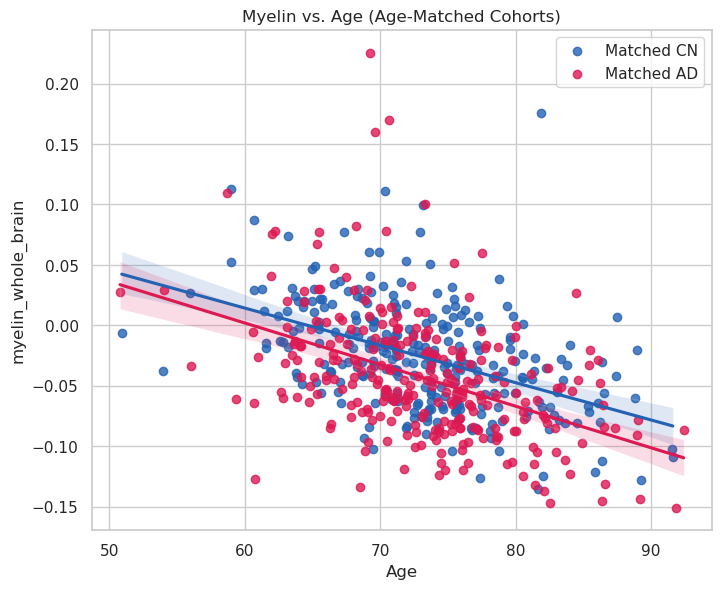

In [17]:
plt.figure(figsize=(8, 6.5))
# Plot Matched CN
sns.regplot(data=matched_cn_df, x='Age', y='myelin_whole_brain', color='#2462B3', label='Matched CN')
# Plot Matched AD
sns.regplot(data=matched_ad_df, x='Age', y='myelin_whole_brain', color='#DD1952', label='Matched AD')
plt.title('Myelin vs. Age (Age-Matched Cohorts)')
plt.legend()
plt.savefig(os.path.join(output_dir, '4_myelin_vs_age_regression(matched_age).png'), dpi=300, bbox_inches='tight')
plt.show()

# Part 5: Netowk specific comparison

#### Network specific statistical comaprison

In [18]:
# Network-specific statistical comparison (independent t-test and p-value correction)

# 1. Whole Population Cohort Comparison
ad_df = df[df['group'] == 'DEMENTED']
cn_df = df[df['group'] == 'NORMCOG']

results_whole = []
for net in list_columns_networks:
    ad_vals = ad_df[net].dropna()
    cn_vals = cn_df[net].dropna()
    t_stat, p_val = ttest_ind(ad_vals, cn_vals, equal_var=False)
    results_whole.append({
        'Network': net,
        't-statistic': t_stat,
        'p-value (uncorrected)': p_val
    })

df_results_whole = pd.DataFrame(results_whole)
df_results_whole['FDR corrected p-value'] = multipletests(df_results_whole['p-value (uncorrected)'], method='fdr_bh')[1]

print("--- Network-Specific Statistical Comparison (Whole Cohort: DEMENTED vs NORMCOG) ---")
print(df_results_whole.to_string(index=False))
print("\n")

# 2. Age-Matched Cohort Comparison
results_matched = []
for net in list_columns_networks:
    ad_vals = matched_ad_df[net].dropna()
    cn_vals = matched_cn_df[net].dropna()
    t_stat, p_val = ttest_ind(ad_vals, cn_vals, equal_var=False)
    results_matched.append({
        'Network': net,
        't-statistic': t_stat,
        'p-value (uncorrected)': p_val
    })

df_results_matched = pd.DataFrame(results_matched)
df_results_matched['FDR corrected p-value'] = multipletests(df_results_matched['p-value (uncorrected)'], method='fdr_bh')[1]

print("--- Network-Specific Statistical Comparison (Age-Matched Cohort) ---")
print(df_results_matched.to_string(index=False))


--- Network-Specific Statistical Comparison (Whole Cohort: DEMENTED vs NORMCOG) ---
           Network  t-statistic  p-value (uncorrected)  FDR corrected p-value
        myelin_Vis    -9.955624           6.141449e-22           1.074754e-21
     myelin_SomMot    -9.671669           4.233316e-21           4.938869e-21
   myelin_DorsAttn    -9.850283           8.597961e-22           1.203715e-21
myelin_SalVentAttn   -14.822997           7.898293e-45           5.528805e-44
     myelin_Limbic    -7.710638           4.930489e-14           4.930489e-14
       myelin_Cont   -11.961839           8.191274e-31           1.911297e-30
    myelin_Default   -13.744379           6.420190e-39           2.247066e-38


--- Network-Specific Statistical Comparison (Age-Matched Cohort) ---
           Network  t-statistic  p-value (uncorrected)  FDR corrected p-value
        myelin_Vis    -2.193752               0.028685               0.028685
     myelin_SomMot    -2.263245               0.024017           

#### Network Boxplots (Age-Matched & Gender-Stratified)**

Figures will be saved in: /home/jovyan/Desktop/PBL_Neuro/postprocessing/Myelin/Scripts/Figures_Class_Distributions

Visual Network (VIN) Mean Myelin Density:
  AD Female: 0.0287
  AD Male: 0.0234
  CN Female: 0.0408
  CN Male: 0.0294


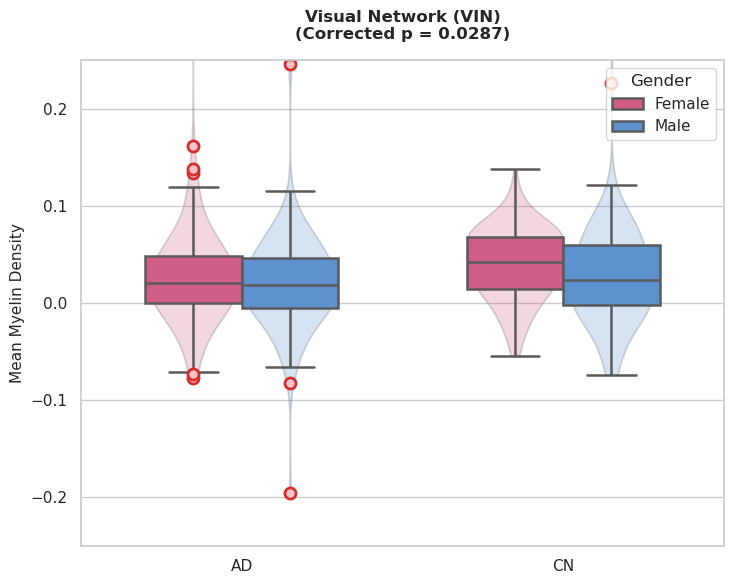


Somatomotor Network (SMN) Mean Myelin Density:
  AD Female: -0.0554
  AD Male: -0.0623
  CN Female: -0.0387
  CN Male: -0.0571


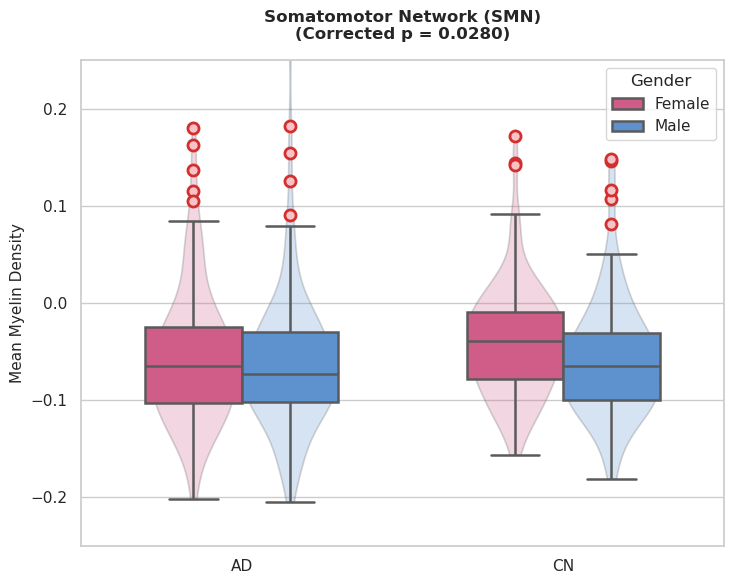


Dorsal Attention Network (DAN) Mean Myelin Density:
  AD Female: -0.0500
  AD Male: -0.0541
  CN Female: -0.0336
  CN Male: -0.0471


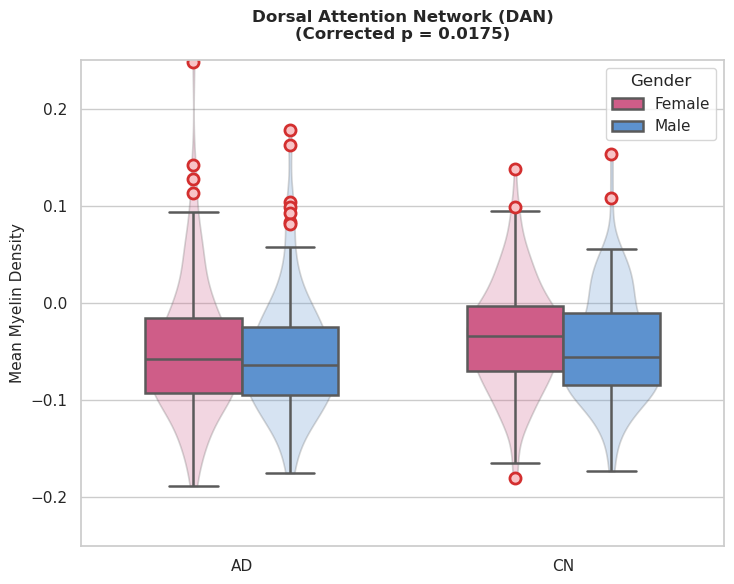


Salience / Ventral Attention Network (SAN/VAN) Mean Myelin Density:
  AD Female: -0.0899
  AD Male: -0.1023
  CN Female: -0.0671
  CN Male: -0.0862


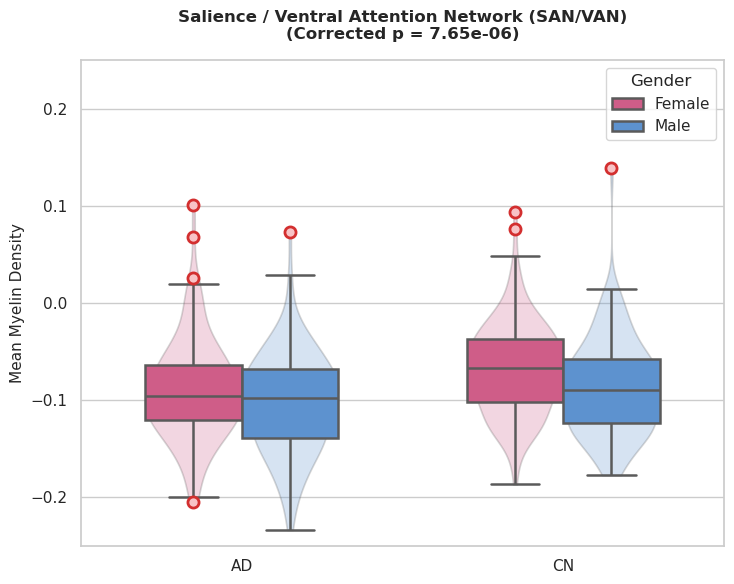


Limbic Network (LIN) Mean Myelin Density:
  AD Female: -0.0167
  AD Male: -0.0233
  CN Female: 0.0061
  CN Male: 0.0042


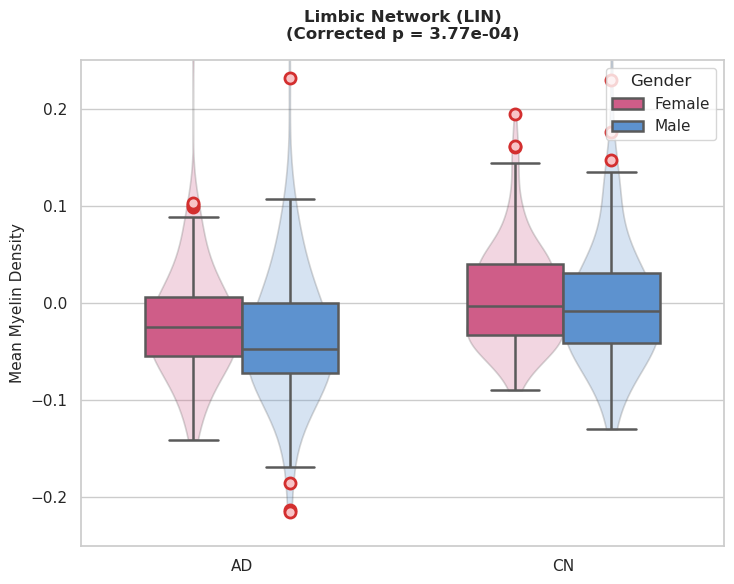


Control / Frontoparietal Network (FPN/CON) Mean Myelin Density:
  AD Female: -0.0406
  AD Male: -0.0501
  CN Female: -0.0210
  CN Male: -0.0374


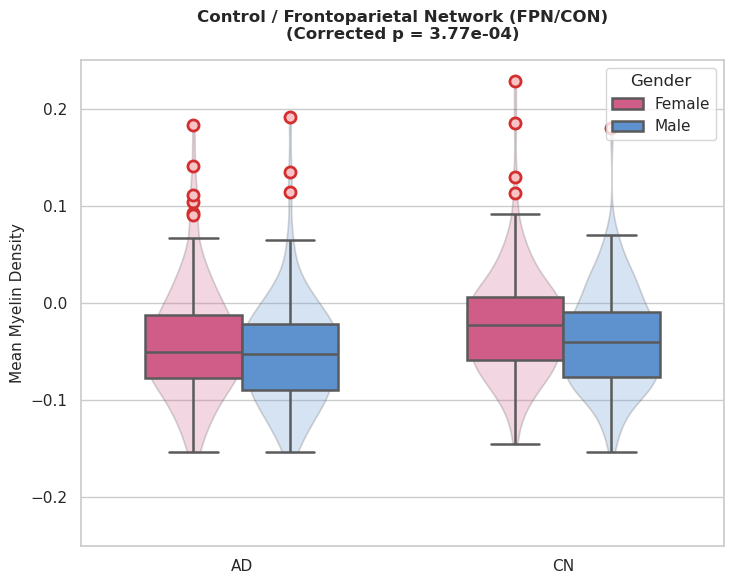


Default Mode Network (DMN) Mean Myelin Density:
  AD Female: -0.0487
  AD Male: -0.0606
  CN Female: -0.0273
  CN Male: -0.0453


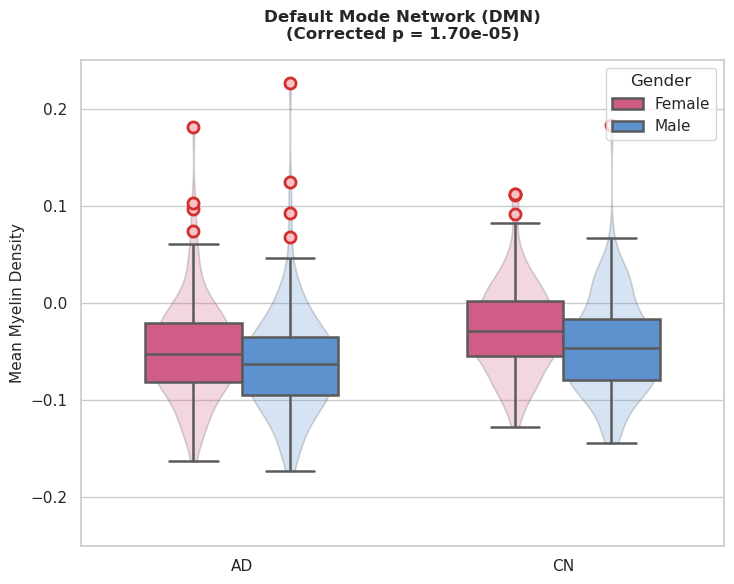

In [19]:
# Define networks, mappings, and outlier properties
networks = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
network_map = {
    "Vis": "Visual Network (VIN)",
    "SomMot": "Somatomotor Network (SMN)",
    "DorsAttn": "Dorsal Attention Network (DAN)",
    "SalVentAttn": "Salience / Ventral Attention Network (SAN/VAN)",
    "Limbic": "Limbic Network (LIN)",
    "Cont": "Control / Frontoparietal Network (FPN/CON)",
    "Default": "Default Mode Network (DMN)"
}

flierprops = dict(marker='o', markerfacecolor='#F8C3C6', markeredgecolor='#D32F2F', markeredgewidth=2, markersize=8, linewidth=2)

# Prepare matched cohort data
matched_ad_df['group_plot'] = 'AD'
matched_cn_df['group_plot'] = 'CN'
matched_cohort = pd.concat([matched_ad_df, matched_cn_df])

# Merge with metadata_df directly using 'Gender'
matched_cohort = pd.merge(matched_cohort, metadata_df[['Subject_ID', 'Gender']], on='Subject_ID', how='inner')

# Map gender values (1 = Male, 2 = Female)
gender_mapping = {1: 'Male', 2: 'Female', '1': 'Male', '2': 'Female'}
matched_cohort['Gender'] = matched_cohort['Gender'].map(gender_mapping)

# Ensure output directory exists (local and container friendly)
fig_dir = output_dir
if not os.path.exists(fig_dir):
    fig_dir = "Figures_Class_Distributions"
    os.makedirs(fig_dir, exist_ok=True)

print(f"Figures will be saved in: {fig_dir}")

# Plotting
sns.set_theme(style="whitegrid")

for net in networks:
    myelin_col = f"myelin_{net}"
    fig, ax = plt.subplots(figsize=(7.5, 6))
    
    # Match width exactly between boxplot and violinplot to ensure perfect visual alignment
    plot_width = 0.6
    hue_order = ["Female", "Male"]
    
    # Create boxplot with Gender as hue
    sns.boxplot(
        data=matched_cohort,
        x="group_plot",
        y=myelin_col,
        hue="Gender",
        hue_order=hue_order,
        palette={"Male": "#4A90E2", "Female": "#E24A84"},
        width=plot_width,
        linewidth=1.8,
        flierprops=flierprops,
        dodge=True,
        ax=ax
    )
    
    # Create violin plot
    sns.violinplot(
        data=matched_cohort,
        x="group_plot",
        y=myelin_col,
        hue="Gender",
        hue_order=hue_order,
        palette={"Male": "#4A90E2", "Female": "#E24A84"},
        width=plot_width,
        inner=None,
        cut=0,
        linewidth=1.2,
        alpha=0.25,
        dodge=True,
        ax=ax
    )
    
    # Get printout of means to display
    means = matched_cohort.groupby(['group_plot', 'Gender'])[myelin_col].mean()
    print(f"\n{network_map[net]} Mean Myelin Density:")
    for (grp, gend), val in means.items():
        print(f"  {grp} {gend}: {val:.4f}")
        
    # Legend handling
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Gender", loc="upper right", frameon=True)
    
    # Retrieve FDR-corrected p-value for the current network from df_results_matched
    fdr_p = df_results_matched.loc[df_results_matched['Network'] == myelin_col, 'FDR corrected p-value'].values[0]
    p_str = f"{fdr_p:.2e}" if fdr_p < 0.001 else f"{fdr_p:.4f}"
    ax.set_title(f"{network_map[net]}\n(Corrected p = {p_str})", fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Mean Myelin Density", fontsize=11)
    
    plt.ylim(-0.25, 0.25)
    plt.tight_layout()
    fig_name = f"boxplot_Myelin_Matched_Gender_{net}.png"
    fig_path = os.path.join(fig_dir, fig_name)
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


Figures will be saved in: /home/jovyan/Desktop/PBL_Neuro/postprocessing/Myelin/Scripts/Figures_Class_Distributions


/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Visual Network (VIN) Mean Myelin Density:
  CN: 0.0360
  AD: 0.0260


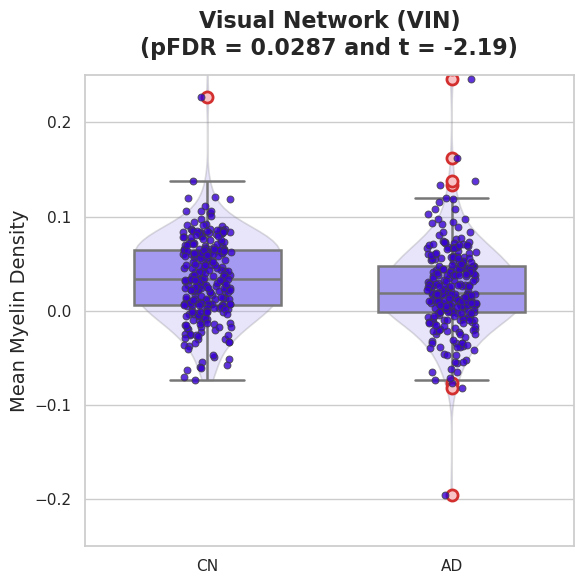

/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Somatomotor Network (SMN) Mean Myelin Density:
  CN: -0.0465
  AD: -0.0590


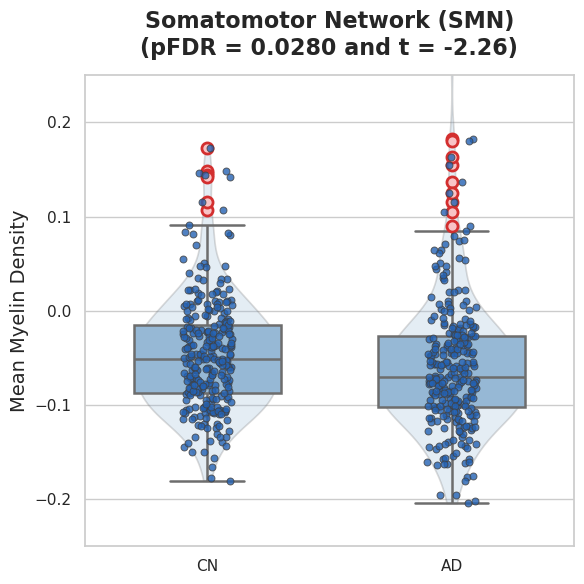

/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Dorsal Attention Network (DAN) Mean Myelin Density:
  CN: -0.0394
  AD: -0.0521


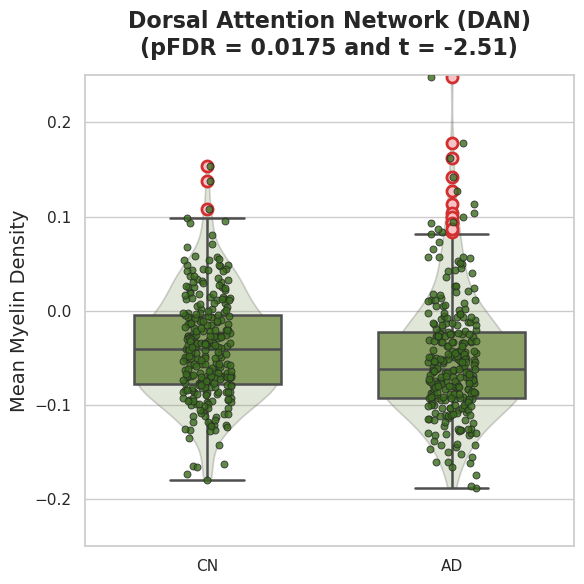

/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Salience / Ventral Attention Network (SAN/VAN) Mean Myelin Density:
  CN: -0.0753
  AD: -0.0963


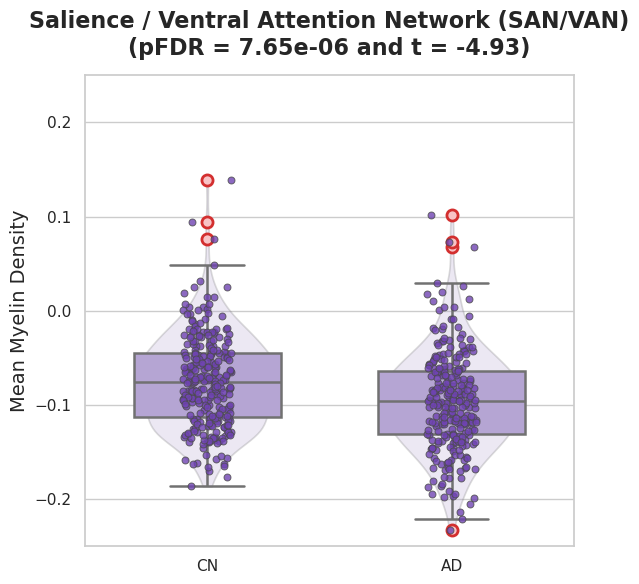

/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Limbic Network (LIN) Mean Myelin Density:
  CN: 0.0053
  AD: -0.0201


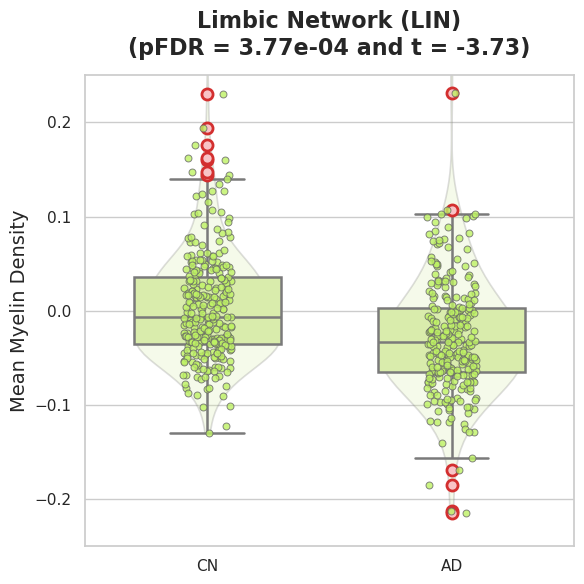

/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Control / Frontoparietal Network (FPN/CON) Mean Myelin Density:
  CN: -0.0280
  AD: -0.0455


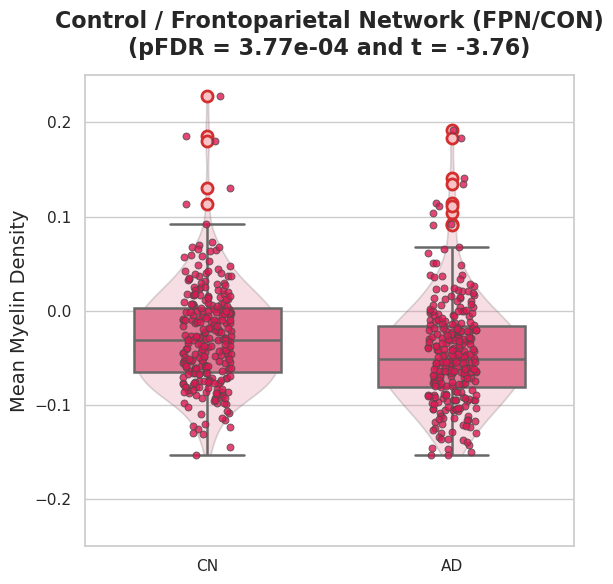

/tmp/ipykernel_3436/2338749382.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(



Default Mode Network (DMN) Mean Myelin Density:
  CN: -0.0350
  AD: -0.0548


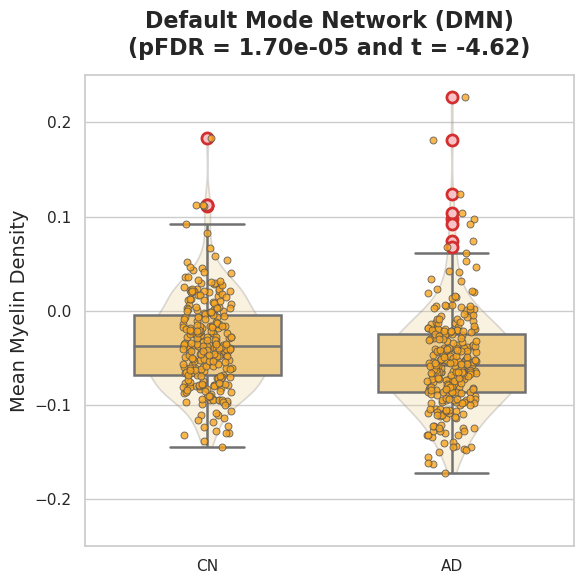

In [21]:
from matplotlib.lines import Line2D

# Define networks, mappings, and outlier properties
networks = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
network_map = {
    "Vis": "Visual Network (VIN)",
    "SomMot": "Somatomotor Network (SMN)",
    "DorsAttn": "Dorsal Attention Network (DAN)",
    "SalVentAttn": "Salience / Ventral Attention Network (SAN/VAN)",
    "Limbic": "Limbic Network (LIN)",
    "Cont": "Control / Frontoparietal Network (FPN/CON)",
    "Default": "Default Mode Network (DMN)"
}

# Define network color mapping (matching 2_plot_myelin_boxplots.py)
light_network_colors = {
    "Vis": "#9A8CFF",
    "SomMot": "#8BB9E0",
    "DorsAttn": "#8DAA5B",
    "SalVentAttn": "#B39DDB",
    "Limbic": "#DDF7A1",
    "Cont": "#F26A8D",
    "Default": "#FFD27A"
}

dark_network_colors = {
    "Vis": "#3700D4",
    "SomMot": "#2462B3",
    "DorsAttn": "#3A6D1C",
    "SalVentAttn": "#6F43B2",
    "Limbic": "#BEF264",
    "Cont": "#DD1952",
    "Default": "#F8A520"
}

flierprops = dict(marker='o', markerfacecolor='#F8C3C6', markeredgecolor='#D32F2F', markeredgewidth=2, markersize=8, linewidth=2)

# Prepare matched cohort data
matched_ad_df['group_plot'] = 'AD'
matched_cn_df['group_plot'] = 'CN'
matched_cohort = pd.concat([matched_ad_df, matched_cn_df])

# Ensure output directory exists (local and container friendly)
fig_dir = output_dir
if not os.path.exists(fig_dir):
    fig_dir = "Figures_Class_Distributions"
    os.makedirs(fig_dir, exist_ok=True)

print(f"Figures will be saved in: {fig_dir}")

# Plotting
sns.set_theme(style="whitegrid")

for net in networks:
    myelin_col = f"myelin_{net}"
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Match width exactly between boxplot and violinplot to ensure perfect visual alignment
    plot_width = 0.6
    order = ["CN", "AD"]
    
    # Define light fill palette for the box and violin plots
    palette = {"CN": light_network_colors[net], "AD": light_network_colors[net]}
    
    # Create boxplot
    sns.boxplot(
        data=matched_cohort,
        x="group_plot",
        y=myelin_col,
        hue="group_plot",
        order=order,
        palette=palette,
        width=plot_width,
        linewidth=1.8,
        flierprops=flierprops,
        ax=ax
    )
    
    # Create violin plot
    sns.violinplot(
        data=matched_cohort,
        x="group_plot",
        y=myelin_col,
        hue="group_plot",
        order=order,
        palette=palette,
        width=plot_width,
        inner=None,
        cut=0,
        linewidth=1.2,
        alpha=0.25,
        ax=ax
    )
    
    # Overlay individual subject points
    sns.stripplot(
        data=matched_cohort,
        x="group_plot",
        y=myelin_col,
        order=order,
        color=dark_network_colors[net],
        jitter=True,
        size=5,
        alpha=0.8,
        marker='o',
        edgecolor='gray',
        linewidth=0.7,
        ax=ax
    )
    
    # Get mean myelin values for the matched cohort
    cn_val = matched_cohort[matched_cohort["group_plot"] == "CN"][myelin_col].mean()
    ad_val = matched_cohort[matched_cohort["group_plot"] == "AD"][myelin_col].mean()
    
    print(f"\n{network_map[net]} Mean Myelin Density:")
    print(f"  CN: {cn_val:.4f}")
    print(f"  AD: {ad_val:.4f}")

    
    # Retrieve FDR-corrected p-value and t-statistic for the current network from df_results_matched
    fdr_p = df_results_matched.loc[df_results_matched['Network'] == myelin_col, 'FDR corrected p-value'].values[0]
    t_stat = df_results_matched.loc[df_results_matched['Network'] == myelin_col, 't-statistic'].values[0]
    p_str = f"{fdr_p:.2e}" if fdr_p < 0.001 else f"{fdr_p:.4f}"
    t_str = f"{t_stat:.2f}"
    ax.set_title(f"{network_map[net]}\n(pFDR = {p_str} and t = {t_str})", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Mean Myelin Density", fontsize=14)
    
    plt.ylim(-0.25, 0.25)
    plt.tight_layout()
    fig_name = f"boxplot_Myelin_Matched_{net}.png"
    fig_path = os.path.join(fig_dir, fig_name)
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)